# Distance Weighting: Exponential Decay

This notebook visualizes the distance-based score component used in the code:

`score_distance = W * exp(-distance_km / S)`

- `W`: distance_weight
- `S`: distance_scale_km


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
from pathlib import Path

# Use a Korean-capable font if available to avoid glyph warnings
def _set_korean_font() -> None:
    candidates = ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Malgun Gothic"]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            mpl.rcParams["font.family"] = name
            break
    mpl.rcParams["axes.unicode_minus"] = False

_set_korean_font()


In [9]:
def distance_score(distance_km: np.ndarray, weight: float, scale_km: float) -> np.ndarray:
    return weight * np.exp(-distance_km / scale_km)


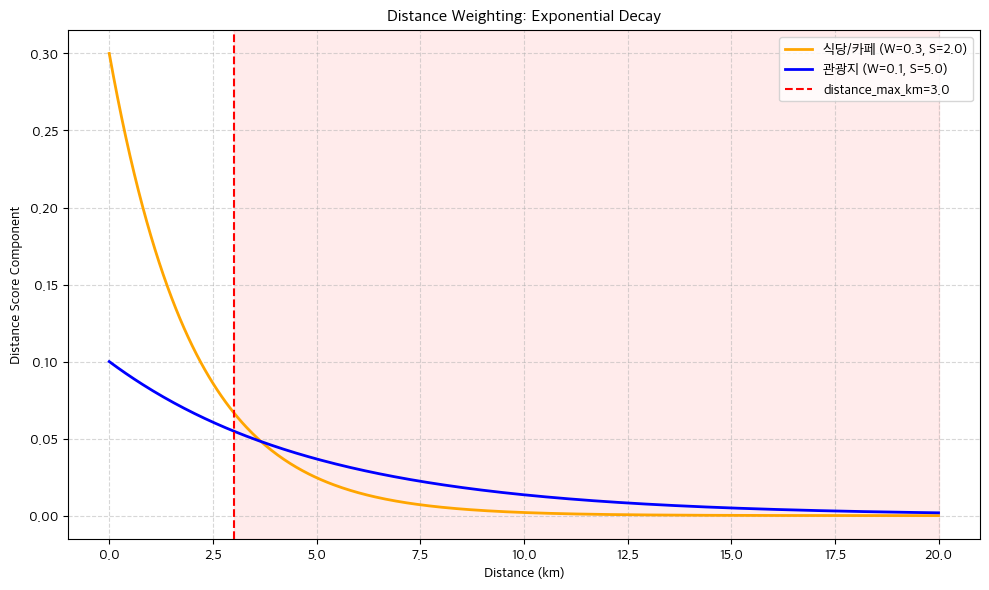

PosixPath('distance_weighting_exponential_decay.png')

In [15]:
# Parameters from the code
tourism = {"label": "관광지 (W=0.1, S=5.0)", "W": 0.1, "S": 5.0}
restaurant_cafe = {"label": "식당/카페 (W=0.3, S=2.0)", "W": 0.3, "S": 2.0}
distance_max_km = 3.0

d = np.linspace(0, 20, 400)
y_tourism = distance_score(d, tourism["W"], tourism["S"])
y_restaurant = distance_score(d, restaurant_cafe["W"], restaurant_cafe["S"])

plt.figure(figsize=(10, 6))
plt.plot(d, y_restaurant, color="orange", linewidth=2, label=restaurant_cafe["label"])
plt.plot(d, y_tourism, color="blue", linewidth=2, label=tourism["label"])

# distance_max_km cutoff
plt.axvline(distance_max_km, color="red", linestyle="--", linewidth=1.5, label=f"distance_max_km={distance_max_km:.1f}")
plt.axvspan(distance_max_km, d.max(), color="red", alpha=0.08)

plt.title("Distance Weighting: Exponential Decay")
plt.xlabel("Distance (km)")
plt.ylabel("Distance Score Component")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

output_path = Path("distance_weighting_exponential_decay.png")
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

output_path
